# Test explanations arrays map to right spectra

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

In [2]:
def load_xai_arrs(run_ids_dict: dict, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_array = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")

    weights_dict = {}

    for n_segments in run_ids_dict.keys():

        run_id = run_ids_dict[n_segments]

        weights_dict[n_segments] = np.load(
            f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r"
        )
    return anomalies_arr, specobjids_array, weights_dict

# Config

## Sample anomalies

In [3]:
se_sample = {
    # unique
    "SE": 2201231682403592192,
    "Filter SE": 2203468363479410688,
    "Trim SE": 312016418084251648,
    "Filter + Trim SE": 2191010072388200448,
    "RSE": 1534667320067123200,
    "Filter RSE": 2032375840699869184,
    "Trim RSE": 1781231151415846912,
    "Filter + Trim RSE": 2486018670363437056,
    # common
    "narrow_line": 734111514142730240,
    "broad_line_large_OIII": 1633733043925575680,
    "broad_emission_dips_OIII_half": 1192355533059811328,
    "star_forming_step_blue_slope": 1959124163192973312,
    "blue_bump_emission": 531492683672217600,
    "passive_star": 1780176998165932032,
    "spike": 1413149843194406912,
    "noise_forest": 637325355518027776,
}

In [4]:
latent_sample = {
    "emission_blue_strong_OII": 1959124163192973312,
    "emission_red_bumpy": 2006491952928811008,
    #
    "strong_emission_no_OII_OIII": 2930814289679771648,
    "broad_OIII_cut": 465054141559891968,
    #
    "broad_strong_emission_OIII": 1633733043925575680,
    "broad_strong_emission_OII_beta_cut": 1189119947666647040,
    #
    "evolved": 1444661293335209984,
    "evolved_artifact": 2217029189603715072,
    #
    "blue": 1119282266950887424,
    "red": 761223822287333376,
}

In [5]:
lof_sample = {
    "evolved": 395359395896125440,
    "evolved_H_alpha": 2501842015717713920,
    "evolved_sf": 873872364331362304,
    "weird_blue_excess": 3243851847563241472,
    "emission_line": 656537668875741184,
}
iforest_sample = {
    "oiii_mgrt_h_alpha": 1928785351883646976,
    "oiii_grt_h_alpha": 1969243798487721984,
    "oiii_sim_h_alpha_no_oii": 749873288389355520,
    "oiii_sim_h_alpha": 2390364730700097536,
    "h_alpha_grt_oiii": 694769887481980928,
}

## Directories

In [6]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
ch_5_dir = f"{thesis_dir}/chapters/05_figures"

## Data

In [7]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")
bin_id = "bin_03"
latent_arr = np.load(f"{latent_dir}/{bin_id}/latent_{bin_id}.npy", mmap_mode="r")

# SE

In [8]:
score_name = "mse"

run_ids_se_dict = {
    "110": "xai_202606230008_uniform_110_samples_5000_scale_0.9",
    "150": "xai_202606230036_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606230118_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

se_anomalies_arr, se_specobjids_array, se_weights_dict = load_xai_arrs(
    run_ids_dict=run_ids_se_dict, load_from=load_from
)

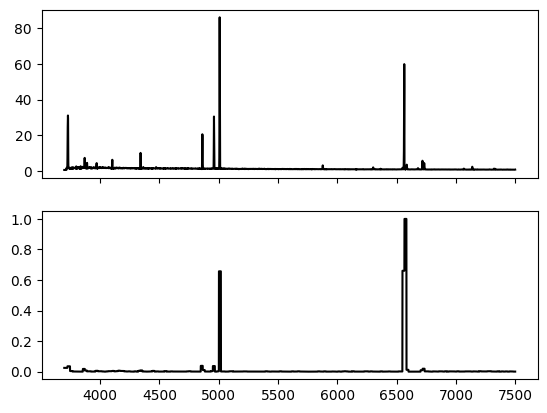

In [9]:
n_segments = "221"
anomaly_name = "narrow_line"

weights = se_weights_dict[n_segments]
specobjid = se_sample[anomaly_name]
idx = np.where(se_specobjids_array == specobjid)[0][0]

weights_abs = np.abs(weights)
weights_abs /= np.max(weights_abs, axis=1, keepdims=True)

fig, axs = plt.subplots(2, 1, figsize=None, sharex=True)
axs[0].plot(wave, se_anomalies_arr[idx, :], color="black")
axs[1].plot(wave, weights_abs[idx, :], color="black")

# Filter SE

In [10]:
score_name = "mse_filter_250"

run_ids_filter_se_dict = {
    "110": "xai_202606230202_uniform_110_samples_5000_scale_0.9",
    "150": "xai_202606230229_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606230243_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

filter_se_anomalies_arr, filter_se_specobjids_array, filter_se_weights_dict = (
    load_xai_arrs(run_ids_dict=run_ids_filter_se_dict, load_from=load_from)
)

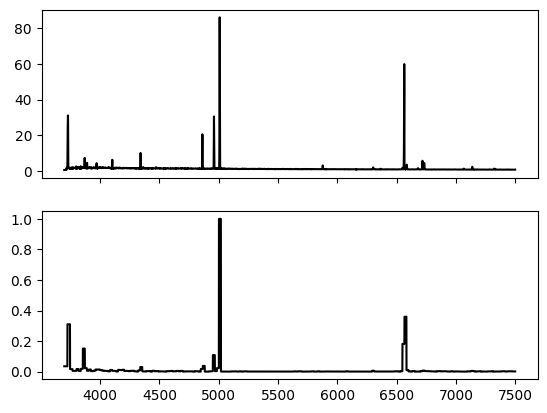

In [11]:
n_segments = "221"
anomaly_name = "narrow_line"

weights = filter_se_weights_dict[n_segments]
specobjid = se_sample[anomaly_name]
idx = np.where(filter_se_specobjids_array == specobjid)[0][0]

weights_abs = np.abs(weights)
weights_abs /= np.max(weights_abs, axis=1, keepdims=True)

fig, axs = plt.subplots(2, 1, figsize=None, sharex=True)
axs[0].plot(wave, filter_se_anomalies_arr[idx, :], color="black")
axs[1].plot(wave, weights_abs[idx, :], color="black")

# Trim SE

In [12]:
score_name = "mse_97"

run_ids_trim_se_dict = {
    "110": "xai_202606250039_uniform_110_samples_5000_scale_0.9",
    "150": "xai_202606250057_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606250112_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

trim_se_anomalies_arr, trim_se_specobjids_array, trim_se_weights_dict = load_xai_arrs(
    run_ids_dict=run_ids_trim_se_dict, load_from=load_from
)

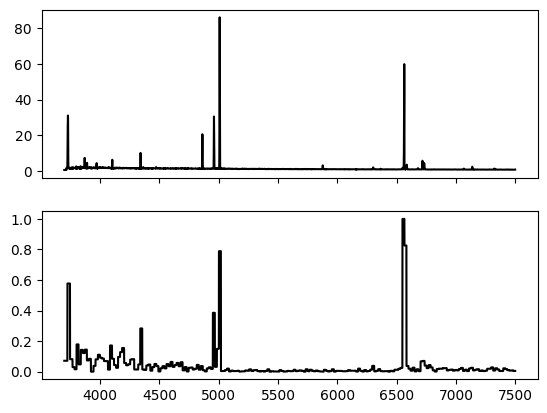

In [13]:
n_segments = "221"
anomaly_name = "narrow_line"

weights = trim_se_weights_dict[n_segments]
specobjid = se_sample[anomaly_name]
idx = np.where(trim_se_specobjids_array == specobjid)[0][0]

weights_abs = np.abs(weights)
weights_abs /= np.max(weights_abs, axis=1, keepdims=True)

fig, axs = plt.subplots(2, 1, figsize=None, sharex=True)
axs[0].plot(wave, trim_se_anomalies_arr[idx, :], color="black")
axs[1].plot(wave, weights_abs[idx, :], color="black")

# Filter + Trim SE

In [14]:
score_name = "mse_filter_250_97"

run_ids_filter_trim_se_dict = {
    "110": "xai_202606250215_uniform_110_samples_5000_scale_0.9",
    "150": "xai_202606252230_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606252251_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

(
    filter_trim_se_anomalies_arr,
    filter_trim_se_specobjids_array,
    filter_trim_se_weights_dict,
) = load_xai_arrs(run_ids_dict=run_ids_filter_trim_se_dict, load_from=load_from)

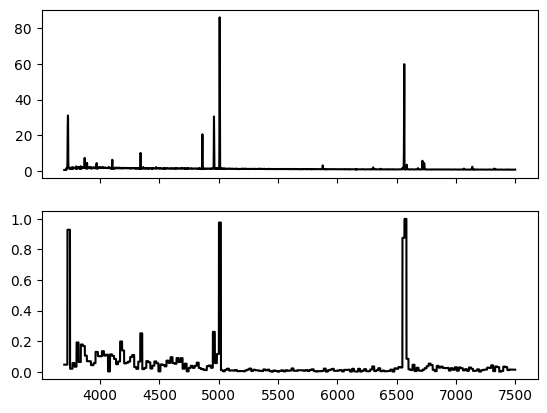

In [15]:
n_segments = "221"
anomaly_name = "narrow_line"

weights = filter_trim_se_weights_dict[n_segments]
specobjid = se_sample[anomaly_name]
idx = np.where(filter_trim_se_specobjids_array == specobjid)[0][0]

weights_abs = np.abs(weights)
weights_abs /= np.max(weights_abs, axis=1, keepdims=True)

fig, axs = plt.subplots(2, 1, figsize=None, sharex=True)
axs[0].plot(wave, filter_trim_se_anomalies_arr[idx, :], color="black")
axs[1].plot(wave, weights_abs[idx, :], color="black")

# RSE

In [16]:
score_name = "mse_rel"

run_ids_rse_dict = {
    "110": "xai_202606231932_uniform_110_samples_5000_scale_0.9",
    "150": "xai_202606231944_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606231955_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

(
    rse_anomalies_arr,
    rse_specobjids_array,
    rse_weights_dict,
) = load_xai_arrs(run_ids_dict=run_ids_rse_dict, load_from=load_from)

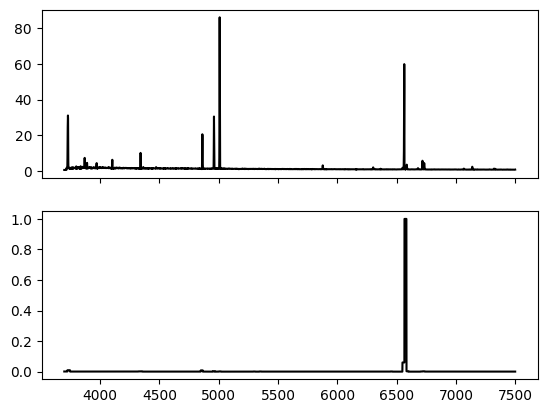

In [17]:
n_segments = "221"
anomaly_name = "narrow_line"

weights = rse_weights_dict[n_segments]
specobjid = se_sample[anomaly_name]
idx = np.where(rse_specobjids_array == specobjid)[0][0]

weights_abs = np.abs(weights)
weights_abs /= np.max(weights_abs, axis=1, keepdims=True)

fig, axs = plt.subplots(2, 1, figsize=None, sharex=True)
axs[0].plot(wave, rse_anomalies_arr[idx, :], color="black")
axs[1].plot(wave, weights_abs[idx, :], color="black")

# Filter RSE

In [18]:
score_name = "mse_filter_250_rel"

run_ids_filter_rse_dict = {
    "110": "xai_202606232009_uniform_110_samples_5000_scale_0.9",
    "150": "xai_202606232020_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606250004_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

(
    filter_rse_anomalies_arr,
    filter_rse_specobjids_array,
    filter_rse_weights_dict,
) = load_xai_arrs(run_ids_dict=run_ids_filter_rse_dict, load_from=load_from)

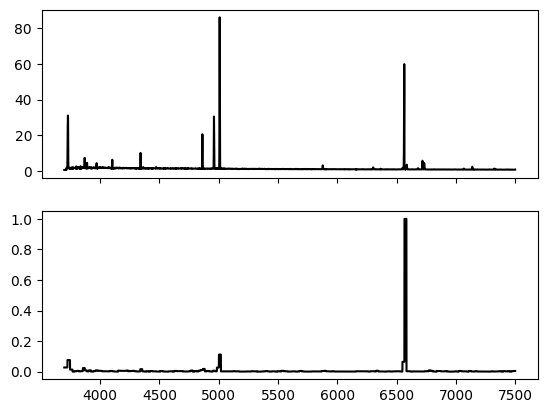

In [19]:
n_segments = "221"
anomaly_name = "narrow_line"

weights = filter_rse_weights_dict[n_segments]
specobjid = se_sample[anomaly_name]
idx = np.where(filter_rse_specobjids_array == specobjid)[0][0]

weights_abs = np.abs(weights)
weights_abs /= np.max(weights_abs, axis=1, keepdims=True)

fig, axs = plt.subplots(2, 1, figsize=None, sharex=True)
axs[0].plot(wave, filter_rse_anomalies_arr[idx, :], color="black")
axs[1].plot(wave, weights_abs[idx, :], color="black")

# Trim RSE

In [20]:
score_name = "mse_97_rel"

run_ids_trim_rse_dict = {
    "110": "xai_202606250127_uniform_110_samples_5000_scale_0.9",
    "150": "xai_202606250146_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606250203_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

(
    trim_rse_anomalies_arr,
    trim_rse_specobjids_array,
    trim_rse_weights_dict,
) = load_xai_arrs(run_ids_dict=run_ids_trim_rse_dict, load_from=load_from)

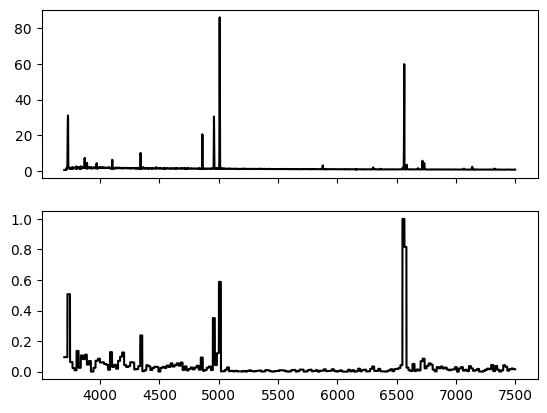

In [21]:
n_segments = "221"
anomaly_name = "narrow_line"

weights = trim_rse_weights_dict[n_segments]
specobjid = se_sample[anomaly_name]
idx = np.where(trim_rse_specobjids_array == specobjid)[0][0]

weights_abs = np.abs(weights)
weights_abs /= np.max(weights_abs, axis=1, keepdims=True)

fig, axs = plt.subplots(2, 1, figsize=None, sharex=True)
axs[0].plot(wave, trim_rse_anomalies_arr[idx, :], color="black")
axs[1].plot(wave, weights_abs[idx, :], color="black")

# Filter + Trim RSE

In [22]:
score_name = "mse_filter_250_97_rel"

run_ids_filter_trim_rse_dict = {
    "110": "xai_202606252304_uniform_110_samples_5000_scale_0.9",
    "150": "xai_202606252342_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606260018_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

(
    filter_trim_rse_anomalies_arr,
    filter_trim_rse_specobjids_array,
    filter_trim_rse_weights_dict,
) = load_xai_arrs(run_ids_dict=run_ids_filter_trim_rse_dict, load_from=load_from)

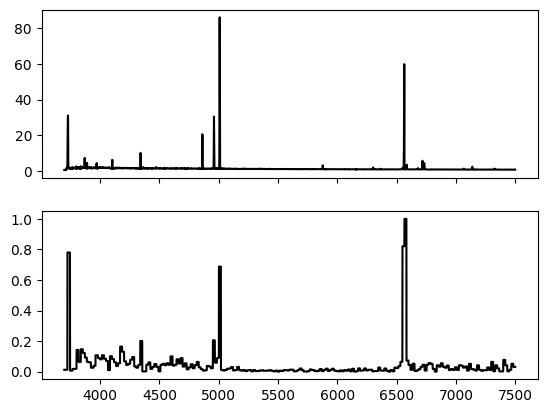

In [23]:
n_segments = "221"
anomaly_name = "narrow_line"

weights = filter_trim_rse_weights_dict[n_segments]
specobjid = se_sample[anomaly_name]
idx = np.where(filter_trim_rse_specobjids_array == specobjid)[0][0]

weights_abs = np.abs(weights)
weights_abs /= np.max(weights_abs, axis=1, keepdims=True)

fig, axs = plt.subplots(2, 1, figsize=None, sharex=True)
axs[0].plot(wave, filter_trim_rse_anomalies_arr[idx, :], color="black")
axs[1].plot(wave, weights_abs[idx, :], color="black")

# Iforest

In [24]:
score_name = "iforest"

run_ids_iforest_dict = {
    "110": "xai_202606211509_uniform_110_samples_50000_scale_0.9",
    "150": "xai_202606211622_uniform_150_samples_50000_scale_0.9",
    "221": "xai_202606222135_uniform_221_samples_50000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}"

(
    iforest_anomalies_arr,
    iforest_specobjids_array,
    iforest_weights_dict,
) = load_xai_arrs(run_ids_dict=run_ids_iforest_dict, load_from=load_from)

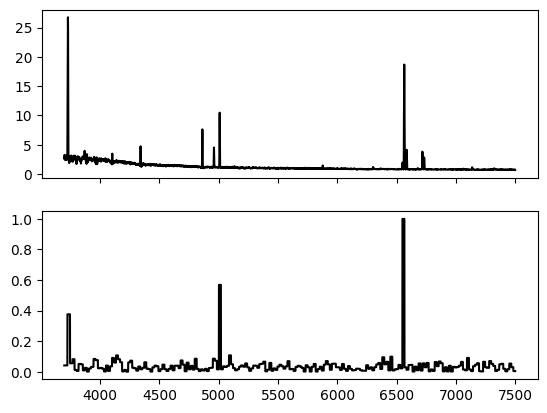

In [25]:
n_segments = "221"
anomaly_name = "emission_blue_strong_OII"

weights = iforest_weights_dict[n_segments]
specobjid = latent_sample[anomaly_name]
idx = np.where(iforest_specobjids_array == specobjid)[0][0]

weights_abs = np.abs(weights)
weights_abs /= np.max(weights_abs, axis=1, keepdims=True)

fig, axs = plt.subplots(2, 1, figsize=None, sharex=True)
axs[0].plot(wave, iforest_anomalies_arr[idx, :], color="black")
axs[1].plot(wave, weights_abs[idx, :], color="black")

# LOF

In [26]:
score_name = "lof"

run_ids_lof_dict = {
    "110": "xai_202606211703_uniform_110_samples_50000_scale_0.9",
    "150": "xai_202606212335_uniform_150_samples_50000_scale_0.9",
    "221": "xai_202606221052_uniform_221_samples_50000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}"

(
    lof_anomalies_arr,
    lof_specobjids_array,
    lof_weights_dict,
) = load_xai_arrs(run_ids_dict=run_ids_lof_dict, load_from=load_from)

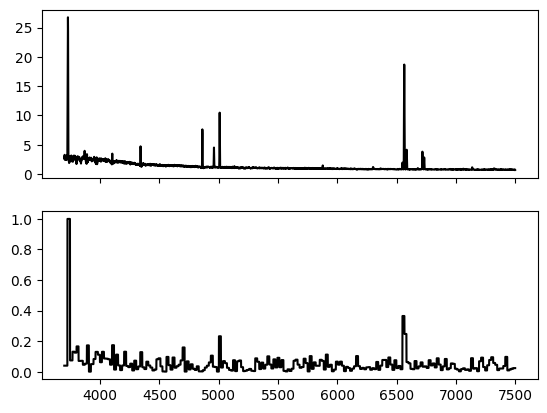

In [27]:
n_segments = "221"
anomaly_name = "emission_blue_strong_OII"

weights = lof_weights_dict[n_segments]
specobjid = latent_sample[anomaly_name]
idx = np.where(lof_specobjids_array == specobjid)[0][0]

weights_abs = np.abs(weights)
weights_abs /= np.max(weights_abs, axis=1, keepdims=True)

fig, axs = plt.subplots(2, 1, figsize=None, sharex=True)
axs[0].plot(wave, lof_anomalies_arr[idx, :], color="black")
axs[1].plot(wave, weights_abs[idx, :], color="black")